# NFL Player Contact Detection: EDA and Tracking Context

This notebook establishes the data profile for the competition and creates the first tracking-distance baseline. It borrows the starter notebook ideas of contact ID parsing, field plots, helmet/video context, and distance thresholding, then organizes them into a reusable EDA workflow.


## 1. Setup and Configuration

Imports, plotting defaults, competition paths, and fast-run flags live in one place so Kaggle runs are easy to audit.


In [4]:
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from IPython.display import display
from sklearn.metrics import matthews_corrcoef
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

RANDOM_STATE = 42
TARGET = "contact"
ID_COL = "contact_id"
RUN_FAST = True
FAST_SAMPLE_PLAYS = 25
DISTANCE_THRESHOLDS = np.round(np.arange(0.2, 3.05, 0.1), 2)

REQUIRED_DATA_FILES = [
    "train_labels.csv",
    "sample_submission.csv",
    "train_player_tracking.csv",
    "test_player_tracking.csv",
    "train_baseline_helmets.csv",
    "test_baseline_helmets.csv",
    "train_video_metadata.csv",
    "test_video_metadata.csv",
]
DATA_DIR_CANDIDATES = [
    Path("/kaggle/input/competitions/nfl-player-contact-detection"),
    Path("/kaggle/input/competitions/1st-and-future-player-contact-detection"),
    Path("/kaggle/input/1st-and-future-player-contact-detection"),
    Path("/kaggle/input/nfl-player-contact-detection"),
    Path("../input/competitions/nfl-player-contact-detection"),
    Path("../input/competitions/1st-and-future-player-contact-detection"),
    Path("../input/1st-and-future-player-contact-detection"),
    Path("../input/nfl-player-contact-detection"),
]


def find_data_dir(
    candidates: list[Path],
    required_files: list[str],
    input_roots: tuple[Path, ...] = (
        Path("/kaggle/input/competitions"),
        Path("/kaggle/input"),
    ),
) -> Path:
    """Find the competition directory that contains the required CSV files."""
    search_paths = list(candidates)
    for input_root in input_roots:
        if input_root.exists():
            search_paths.extend(
                path for path in input_root.iterdir() if path.is_dir()
            )

    seen = set()
    for path in search_paths:
        path = path.resolve() if path.exists() else path
        if path in seen:
            continue
        seen.add(path)
        if all((path / filename).exists() for filename in required_files):
            return path

    available = {}
    for input_root in input_roots:
        if input_root.exists():
            available[str(input_root)] = sorted(
                path.name for path in input_root.iterdir()
            )
    raise FileNotFoundError(
        "Could not find the NFL contact detection data directory. "
        f"Checked: {[str(path) for path in search_paths]}. "
        f"Available input directories: {available}"
    )


DATA_DIR = find_data_dir(DATA_DIR_CANDIDATES, REQUIRED_DATA_FILES)
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")

print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")


DATA_DIR: /kaggle/input/competitions/nfl-player-contact-detection
OUTPUT_DIR: /kaggle/working


## 2. Helper Functions

These small utilities keep parsing, memory reduction, field plotting, and distance scoring consistent across the EDA and baseline notebooks.


In [5]:
def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast dataframe columns to reduce notebook memory usage."""
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if pd.api.types.is_integer_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(dtype):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5 and col != ID_COL:
                out[col] = out[col].astype("category")
    return out


def parse_contact_id(df: pd.DataFrame) -> pd.DataFrame:
    """Split Kaggle contact_id into play, step, player1, and player2 fields."""
    out = df.copy()
    parts = out[ID_COL].astype(str).str.split("_", expand=True)
    out["game_play"] = parts[0] + "_" + parts[1]
    out["step"] = parts[2].astype("int16")
    out["nfl_player_id_1"] = parts[3].astype(str)
    out["nfl_player_id_2"] = parts[4].astype(str)
    out["contact_type"] = np.where(
        out["nfl_player_id_2"].eq("G"), "ground", "player_player"
    )
    return out


def dataframe_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Summarize column types, missingness, unique values, and memory."""
    return pd.DataFrame({
        "dataset": name,
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
        "unique": df.nunique(dropna=False),
        "memory_mb": df.memory_usage(deep=True).div(1024 ** 2),
    }).sort_values(["missing_pct", "unique"], ascending=[False, False])


def maybe_sample_plays(df: pd.DataFrame, n_plays: int) -> pd.DataFrame:
    """Return all rows for a reproducible sample of game_play values."""
    plays = pd.Series(df["game_play"].unique()).sample(
        min(n_plays, df["game_play"].nunique()),
        random_state=RANDOM_STATE,
    )
    return df[df["game_play"].isin(plays)].copy()


def create_football_field(
    linenumbers: bool = True,
    endzones: bool = True,
    figsize: tuple[int, int] = (12, 6),
    line_color: str = "black",
    field_color: str = "white",
    endzone_color=None,
    ax=None,
):
    """Draw a football field for tracking-data visualization."""
    if endzone_color is None:
        endzone_color = field_color
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    rect = patches.Rectangle(
        (0, 0), 120, 53.3, linewidth=0.1, edgecolor=line_color,
        facecolor=field_color, zorder=0,
    )
    ax.add_patch(rect)

    for x in range(10, 120, 10):
        ax.plot([x, x], [0, 53.3], color=line_color, linewidth=0.8)
    if endzones:
        ax.add_patch(patches.Rectangle(
            (0, 0), 10, 53.3, linewidth=0.1, edgecolor=line_color,
            facecolor=endzone_color, alpha=0.5, zorder=0,
        ))
        ax.add_patch(patches.Rectangle(
            (110, 0), 10, 53.3, linewidth=0.1, edgecolor=line_color,
            facecolor=endzone_color, alpha=0.5, zorder=0,
        ))

    if linenumbers:
        for x in range(20, 110, 10):
            number = x if x <= 50 else 120 - x
            label = str(number - 10)
            ax.text(x, 5, label, ha="center", fontsize=16, color=line_color)
            ax.text(
                x, 48.3, label, ha="center", fontsize=16,
                color=line_color, rotation=180,
            )

    hash_range = range(11, 110) if endzones else range(1, 120)
    for x in hash_range:
        ax.plot([x, x], [0.4, 0.7], color=line_color, linewidth=0.6)
        ax.plot([x, x], [52.6, 52.9], color=line_color, linewidth=0.6)
        ax.plot([x, x], [22.91, 23.57], color=line_color, linewidth=0.6)
        ax.plot([x, x], [29.73, 30.39], color=line_color, linewidth=0.6)

    ax.set_xlim(-5, 125)
    ax.set_ylim(-5, 58.3)
    ax.axis("off")
    return ax


def compute_pair_distances(
    contacts: pd.DataFrame,
    tracking: pd.DataFrame,
) -> pd.DataFrame:
    """Attach player coordinates and compute player-player distance in yards."""
    pairs = contacts[contacts["nfl_player_id_2"].ne("G")].copy()
    track_cols = [
        "game_play", "step", "nfl_player_id", "x_position", "y_position"
    ]
    track = tracking[track_cols].copy()
    for col in ["nfl_player_id", "nfl_player_id_1", "nfl_player_id_2"]:
        if col in track.columns:
            track[col] = track[col].astype(str)
        if col in pairs.columns:
            pairs[col] = pairs[col].astype(str)

    out = pairs.merge(
        track,
        left_on=["game_play", "step", "nfl_player_id_1"],
        right_on=["game_play", "step", "nfl_player_id"],
        how="left",
    ).rename(columns={
        "x_position": "x_position_1",
        "y_position": "y_position_1",
    }).drop(columns=["nfl_player_id"])

    out = out.merge(
        track,
        left_on=["game_play", "step", "nfl_player_id_2"],
        right_on=["game_play", "step", "nfl_player_id"],
        how="left",
    ).rename(columns={
        "x_position": "x_position_2",
        "y_position": "y_position_2",
    }).drop(columns=["nfl_player_id"])

    out["distance"] = np.sqrt(
        np.square(out["x_position_1"] - out["x_position_2"])
        + np.square(out["y_position_1"] - out["y_position_2"])
    )
    return out


def score_distance_thresholds(
    df: pd.DataFrame,
    thresholds: np.ndarray,
) -> pd.DataFrame:
    """Score distance thresholds while predicting ground rows as no-contact."""
    rows = []
    y_true = df[TARGET].astype(int).to_numpy()
    contact_type = df["contact_type"].to_numpy()
    distances = df["distance"].to_numpy()
    is_pair = contact_type == "player_player"

    for threshold in thresholds:
        pred = np.zeros(len(df), dtype=np.int8)
        pred[is_pair] = np.nan_to_num(distances[is_pair], nan=np.inf) <= threshold
        rows.append({
            "threshold": threshold,
            "mcc": matthews_corrcoef(y_true, pred),
            "positive_rate": pred.mean(),
        })
    return pd.DataFrame(rows).sort_values("mcc", ascending=False)


## 3. Load Data

Read the core competition tables. The notebook expects Kaggle's fixed input path, with a local fallback for downloaded data.


In [6]:
labels = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "train_labels.csv",
    parse_dates=["datetime"],
))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
train_tracking = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "train_player_tracking.csv",
    parse_dates=["datetime"],
))
test_tracking = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "test_player_tracking.csv",
    parse_dates=["datetime"],
))
train_helmets = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "train_baseline_helmets.csv",
))
test_helmets = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "test_baseline_helmets.csv",
))
train_video_metadata = pd.read_csv(
    DATA_DIR / "train_video_metadata.csv",
    parse_dates=["start_time", "end_time", "snap_time"],
)
test_video_metadata = pd.read_csv(
    DATA_DIR / "test_video_metadata.csv",
    parse_dates=["start_time", "end_time", "snap_time"],
)

labels = parse_contact_id(labels)
sample_submission = parse_contact_id(sample_submission)

print(f"labels: {labels.shape}")
print(f"sample_submission: {sample_submission.shape}")
print(f"train_tracking: {train_tracking.shape}")
print(f"test_tracking: {test_tracking.shape}")
print(f"train_helmets: {train_helmets.shape}")
print(f"test_helmets: {test_helmets.shape}")
print(f"train_video_metadata: {train_video_metadata.shape}")
print(f"test_video_metadata: {test_video_metadata.shape}")
labels.head()


labels: (4721618, 8)
sample_submission: (49588, 7)
train_tracking: (1353053, 17)
test_tracking: (14872, 17)
train_helmets: (3783616, 12)
test_helmets: (47330, 12)
train_video_metadata: (480, 7)
test_video_metadata: (4, 7)


,contact_id,game_play,datetime,step,nfl_player_id_1,nfl_player_id_2,contact,contact_type
0,58168_003392_0_38590_43854,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,43854,0,player_player
1,58168_003392_0_38590_41257,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,41257,0,player_player
2,58168_003392_0_38590_41944,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,41944,0,player_player
3,58168_003392_0_38590_42386,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,42386,0,player_player
4,58168_003392_0_38590_47944,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,47944,0,player_player


## 4. Data Quality

Check schema shape, missingness, duplicates, ID parsing, and basic play coverage before interpreting any signal.


In [7]:
quality_checks = pd.DataFrame({
    "check": [
        "duplicated label rows",
        "duplicated contact_id",
        "label game_play count",
        "tracking game_play count",
        "sample game_play count",
    ],
    "value": [
        int(labels.duplicated().sum()),
        int(labels[ID_COL].duplicated().sum()),
        int(labels["game_play"].nunique()),
        int(train_tracking["game_play"].nunique()),
        int(sample_submission["game_play"].nunique()),
    ],
})

display(pd.concat([
    dataframe_overview(labels, "labels"),
    dataframe_overview(train_tracking, "train_tracking"),
    dataframe_overview(train_helmets, "train_helmets"),
]))
display(quality_checks)


,dataset,dtype,missing,missing_pct,unique,memory_mb
contact_id,labels,object,0.0,0.0,4721618.0,340.181390
datetime,labels,"datetime64[ns, UTC]",0.0,0.0,18666.0,36.023087
nfl_player_id_1,labels,object,0.0,0.0,1687.0,243.155834
nfl_player_id_2,labels,object,0.0,0.0,1646.0,241.589394
game_play,labels,object,0.0,0.0,240.0,274.676035
step,labels,int16,0.0,0.0,173.0,9.005772
contact,labels,int8,0.0,0.0,2.0,4.502886
contact_type,labels,object,0.0,0.0,2.0,276.437650
Index,labels,NaN,NaN,NaN,NaN,0.000126
datetime,train_tracking,"datetime64[ns, UTC]",0.0,0.0,61279.0,10.322975


,check,value
0,duplicated label rows,0
1,duplicated contact_id,0
2,label game_play count,240
3,tracking game_play count,240
4,sample game_play count,2


## 5. Contact Label Balance

Measure the target balance overall and separately for player-player and player-ground rows. This split matters because the starter distance baseline only models player-player contact.


,count,contact_rate,positive_count
contact_type,,,
ground,410633,0.040947,16814
player_player,4310985,0.011067,47708


Overall contact rate: 0.01367


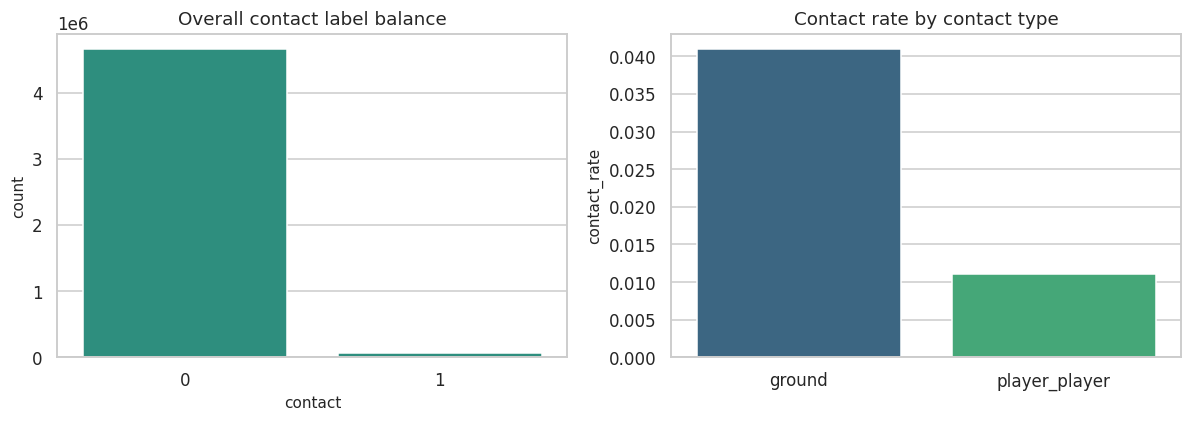

In [8]:
label_summary = (
    labels.groupby("contact_type", observed=True)[TARGET]
    .agg(["count", "mean", "sum"])
    .rename(columns={"mean": "contact_rate", "sum": "positive_count"})
)
display(label_summary)
print(f"Overall contact rate: {labels[TARGET].mean():.5f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=labels, x=TARGET, color=sns.color_palette("viridis", 8)[4], ax=axes[0])
axes[0].set_title("Overall contact label balance")
sns.barplot(
    data=label_summary.reset_index(),
    x="contact_type",
    y="contact_rate",
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title("Contact rate by contact type")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()


### Label Takeaway

Player-player and ground contact are related but different prediction problems. The first distance experiment is useful for player-player rows; ground rows need a dedicated branch in later notebooks.


## 6. Tracking Context

Inspect tracking columns and movement distributions. Position and motion fields are the foundation for distance, relative speed, and temporal features.


,count,mean,std,min,25%,50%,75%,max
game_key,1353053.0,58365.798892,137.696060,58168.00,58225.000000,58330.000000,58516.000000,58582.000000
play_id,1353053.0,2156.408095,1211.457383,40.00,1016.000000,2369.000000,3139.000000,4644.000000
nfl_player_id,1353053.0,44747.017081,4831.883106,25511.00,42352.000000,44893.000000,47814.000000,53985.000000
step,1353053.0,-11.900465,112.549475,-339.00,-86.000000,-15.000000,49.000000,692.000000
jersey_number,1353053.0,51.282450,28.636098,1.00,25.000000,52.000000,76.000000,99.000000
x_position,1353053.0,60.308060,26.804514,-7.47,38.480000,59.689999,81.709999,125.650002
y_position,1353053.0,26.758907,8.502809,-12.87,22.490000,26.740000,31.040001,63.720001
speed,1353053.0,1.259892,1.656287,0.00,0.120000,0.650000,1.620000,14.890000
distance,1353053.0,0.128708,0.166279,0.00,0.020000,0.070000,0.160000,2.220000
direction,1353053.0,179.698868,103.967316,0.00,90.029999,179.240005,269.329987,360.000000


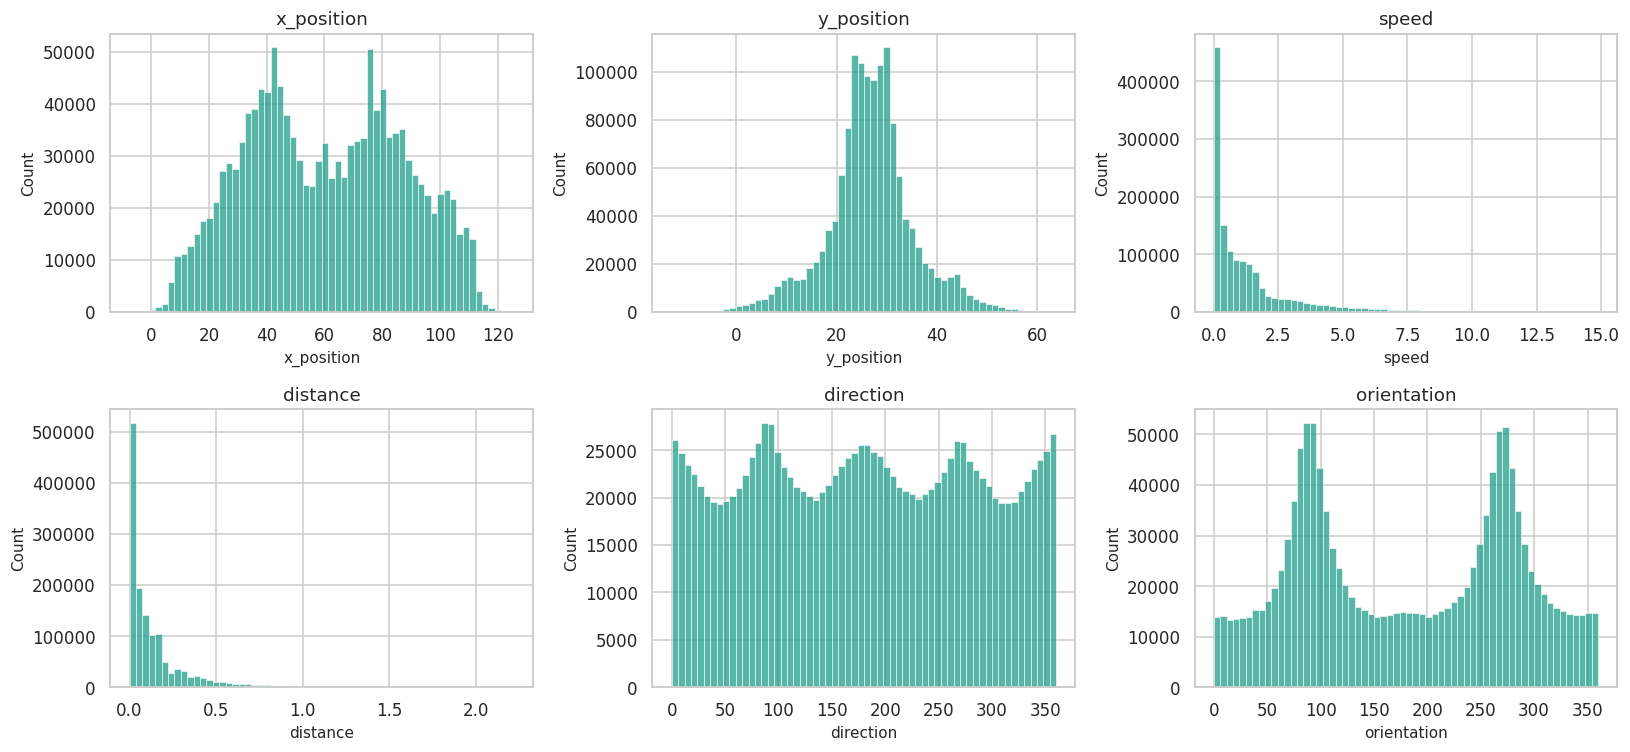

In [9]:
tracking_numeric = train_tracking.select_dtypes(include=[np.number]).columns.tolist()
display(train_tracking[tracking_numeric].describe().T)

plot_cols = [
    col for col in ["x_position", "y_position", "speed", "distance", "direction", "orientation"]
    if col in train_tracking.columns
]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = np.ravel(axes)
for ax, col in zip(axes, plot_cols):
    sns.histplot(train_tracking[col].dropna(), bins=60, color=sns.color_palette("viridis", 8)[4], ax=ax)
    ax.set_title(col)
for ax in axes[len(plot_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Helmet and Video Metadata Context

Summarize baseline helmet boxes and video timing metadata. These tables become important when we move beyond tracking-only features.


In [10]:
helmet_summary = pd.DataFrame({
    "dataset": ["train_helmets", "test_helmets"],
    "rows": [len(train_helmets), len(test_helmets)],
    "videos": [train_helmets["video"].nunique(), test_helmets["video"].nunique()],
    "game_plays": [train_helmets["game_play"].nunique(), test_helmets["game_play"].nunique()],
    "players": [train_helmets["nfl_player_id"].nunique(), test_helmets["nfl_player_id"].nunique()],
})
display(helmet_summary)

video_summary = pd.concat([
    train_video_metadata.assign(dataset="train"),
    test_video_metadata.assign(dataset="test"),
], ignore_index=True)
display(video_summary.head())
display(video_summary.groupby(["dataset", "view"]).agg(
    videos=("video", "count"),
    game_plays=("game_play", "nunique"),
))

box_cols = [c for c in ["left", "width", "top", "height"] if c in train_helmets]
if box_cols:
    display(train_helmets[box_cols].describe().T)


,dataset,rows,videos,game_plays,players
0,train_helmets,3783616,481,240,1687
1,test_helmets,47330,4,2,44


,game_play,game_key,play_id,view,start_time,end_time,snap_time,dataset
0,58168_003392,58168,3392,Endzone,2020-09-11 03:01:43.134000+00:00,2020-09-11 03:01:54.971000+00:00,2020-09-11 03:01:48.134000+00:00,train
1,58168_003392,58168,3392,Sideline,2020-09-11 03:01:43.134000+00:00,2020-09-11 03:01:54.971000+00:00,2020-09-11 03:01:48.134000+00:00,train
2,58172_003247,58172,3247,Endzone,2020-09-13 19:30:42.414000+00:00,2020-09-13 19:31:00.524000+00:00,2020-09-13 19:30:47.414000+00:00,train
3,58172_003247,58172,3247,Sideline,2020-09-13 19:30:42.414000+00:00,2020-09-13 19:31:00.524000+00:00,2020-09-13 19:30:47.414000+00:00,train
4,58173_003606,58173,3606,Endzone,2020-09-13 19:45:07.527000+00:00,2020-09-13 19:45:26.438000+00:00,2020-09-13 19:45:12.527000+00:00,train


KeyError: "Column(s) ['video'] do not exist"

## 8. Example Field View

Plot one play and step on a football field to verify coordinate orientation and team separation.


In [ ]:
example_game_play = labels["game_play"].iloc[0]
example_step = int(labels.loc[labels["game_play"].eq(example_game_play), "step"].median())
example_tracking = train_tracking.query(
    "game_play == @example_game_play and step == @example_step"
).copy()

fig, ax = plt.subplots(figsize=(12, 6))
create_football_field(ax=ax)
if len(example_tracking):
    sns.scatterplot(
        data=example_tracking,
        x="x_position",
        y="y_position",
        hue="team",
        palette="viridis",
        s=80,
        ax=ax,
    )
    ax.set_title(f"{example_game_play}, step {example_step}")
plt.show()


## 9. Distance Baseline Sanity Check

Tune player-player distance thresholds with a play-grouped validation split. Ground rows are predicted as no-contact in this first baseline so the limitation is explicit.


In [ ]:
work_labels = labels[[
    ID_COL, TARGET, "game_play", "step", "nfl_player_id_1",
    "nfl_player_id_2", "contact_type",
]].copy()
if RUN_FAST:
    work_labels = maybe_sample_plays(work_labels, FAST_SAMPLE_PLAYS)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE,
)
_, valid_idx = next(splitter.split(work_labels, groups=work_labels["game_play"]))
valid_labels = work_labels.iloc[valid_idx].copy()

valid_distances = compute_pair_distances(valid_labels, train_tracking)
valid_scoring = valid_labels.merge(
    valid_distances[[ID_COL, "distance"]],
    on=ID_COL,
    how="left",
)
threshold_scores = score_distance_thresholds(
    valid_scoring,
    DISTANCE_THRESHOLDS,
)
best_threshold = float(threshold_scores.iloc[0]["threshold"])
best_mcc = float(threshold_scores.iloc[0]["mcc"])

print(f"Validation rows: {len(valid_scoring):,}")
print(f"Best threshold: {best_threshold:.2f} yards")
print(f"Best MCC: {best_mcc:.5f}")
display(threshold_scores.head(10))

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=threshold_scores.sort_values("threshold"), x="threshold", y="mcc", marker="o", ax=ax)
ax.axvline(best_threshold, color="black", linestyle="--", linewidth=1)
ax.set_title("Distance threshold validation MCC")
plt.show()

gc.collect()


### Baseline Takeaway

A tuned distance threshold is a clean first experiment and a useful validation harness. Its main weakness is structural: it cannot detect ground contact, and it sees only player centers rather than body posture or video evidence.
